<a href="https://colab.research.google.com/github/rindaaditiya28-cmyk/linear-regression-taksi/blob/main/FSD_P8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama:
- Aura Dwika Medriana (24523174)
- Rinda Aditiya (24523194)

**PreProcessing Data**

kami menggunakan Dataset klasifikasi Dynamic Apparel Sales Dataset. https://www.kaggle.com/datasets/rayzem/dynamic-apparel-sales-dataset-with-anomalies?resource=download


In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

nama_file = 'Multiclass Clothing Sales Dataset.csv'

path_asli = None
for root, dirs, files in os.walk("/"):
    if nama_file in files:
        path_asli = os.path.join(root, nama_file)
        break

if path_asli:
    print(f"✓ File ditemukan di lokasi: {path_asli}")
    df = pd.read_csv(path_asli)
    print("✓ Dataset berhasil dibaca!")
    print(df.head(2))

    df = df.dropna()

    # 3. MEMISAHKAN FITUR DAN TARGET
    target_column = df.columns[-1]
    print(f"Target klasifikasi yang digunakan: '{target_column}'")

    X = df.drop(columns=[target_column])
    y = df[target_column]

    kolom_tidak_dipakai = ['Product_ID', 'Date', 'Transaction_ID', 'Unnamed: 0']
    X = X.drop(columns=kolom_tidak_dipakai, errors='ignore')

    # 4. ENCODING (Mengubah data teks kategori menjadi angka)
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

    le_target = LabelEncoder()
    y = le_target.fit_transform(y)

    # 5. SCALING DATA
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print("\n✓ Langkah 2 (Preprocessing) SUKSES SELESAI!")
else:
    print(f"❌ ERROR: File '{nama_file}' benar-benar tidak ditemukan di sistem Colab.")
    print("Coba klik kanan pada file tersebut di panel kiri Colab, pilih 'Copy path', lalu paste di variabel 'nama_file'.")

✓ File ditemukan di lokasi: /Multiclass Clothing Sales Dataset.csv
✓ Dataset berhasil dibaca!
   Product_Category         Brand  Product_Name Gender Size   Color  \
0  Traditional Wear    Forever 21          Tops  Women    S   White   
1        Athleisure  Ralph Lauren  Casual Shirt    Men  XXL  Yellow   

       Season Payment_Method Customer_Type  Selling_Price  Cost_Price  \
0      Winter           Card           New    1817.433878  816.027585   
1  All-Season           Card     Returning    1672.038198  793.236861   

   Discount_Percentage  Quantity_Sold   Total_Sales  Stock_Availability  \
0            26.260791              6  42241.692855               294.0   
1            26.882613              8  69318.541482               376.0   

   Customer_Age  Purchase_Frequency  Store_Rating  Return_Rate Sales_Category  
0          58.0            2.560957      3.106155    29.293331     High Sales  
1          40.0            1.590993      3.428439    19.473670      Low Sales  
Target

**Split Data**

In [ ]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi train set (80%) dan test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("=== LANGKAH 3: HASIL SPLIT DATA ===")
print(f"Jumlah Baris Data Latih (X_train) : {X_train.shape[0]}")
print(f"Jumlah Baris Data Uji (X_test)   : {X_test.shape[0]}")

=== LANGKAH 3: HASIL SPLIT DATA ===
Jumlah Baris Data Latih (X_train) : 61838
Jumlah Baris Data Uji (X_test)   : 15460


**Modeling SVM**

In [ ]:
from sklearn.svm import SVC

# Membuat model SVM dengan Kernel RBF
model_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# Melatih model dengan data train
model_svm.fit(X_train, y_train)

print("=== LANGKAH 4: MODELING SVM ===")
print("Model SVM dengan Kernel RBF berhasil dibuat dan dilatih!")

Kernel yang digunakan adalah RBF (Radial Basis Function). Alasan memilih itu karena dataset penjualan pakaian memiliki hubungan antar-atribut yang kompleks dan non-linear, sehingga kernel RBF sangat andal dalam memetakan data tersebut ke dimensi yang lebih tinggi agar kelas targetnya mudah dipisahkan oleh algoritma SVM.  

**Evaluasi Model**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Prediksi data uji dan data latih
y_pred_test = model_svm.predict(X_test)
y_pred_train = model_svm.predict(X_train)

# Hitung metrik evaluasi
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)

print("=== LANGKAH 5: HASIL EVALUASI MODEL SVM ===")
print(f"Accuracy  : {acc*100:.2f}%")
print(f"Precision : {prec*100:.2f}%")
print(f"Recall    : {rec*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")

# Cek Overfitting / Underfitting
acc_train = accuracy_score(y_train, y_pred_train)
print(f"\nAkurasi Data Latih (Train Acc) : {acc_train*100:.2f}%")
print(f"Akurasi Data Uji (Test Acc)   : {acc*100:.2f}%")

=== LANGKAH 5: HASIL EVALUASI MODEL SVM ===
Accuracy  : 32.99%
Precision : 33.00%
Recall    : 32.99%
F1 Score  : 32.98%

Akurasi Data Latih (Train Acc) : 44.67%
Akurasi Data Uji (Test Acc)   : 32.99%


Berdasarkan hasilnya, model SVM ini mengalami Underfitting. Hal ini ditunjukkan oleh nilai akurasi pada data latih (Train Accuracy) yang sangat rendah, yaitu hanya 44.67%, dan akurasi pada data uji (Test Accuracy) sebesar 32.99%.

Karena performa pada saat pelatihan (data latih) maupun pengujian (data uji) sama-sama rendah (di bawah 50%), ini berarti model SVM dengan parameter saat ini gagal menangkap pola atau karakteristik penting yang ada di dalam dataset penjualan pakaian. Model tidak mampu mempelajari relasi antara fitur-fitur pakaian dengan kelas targetnya dengan baik.

**Visualisasi**

=== LANGKAH 6: MEMPROSES VISUALISASI ===


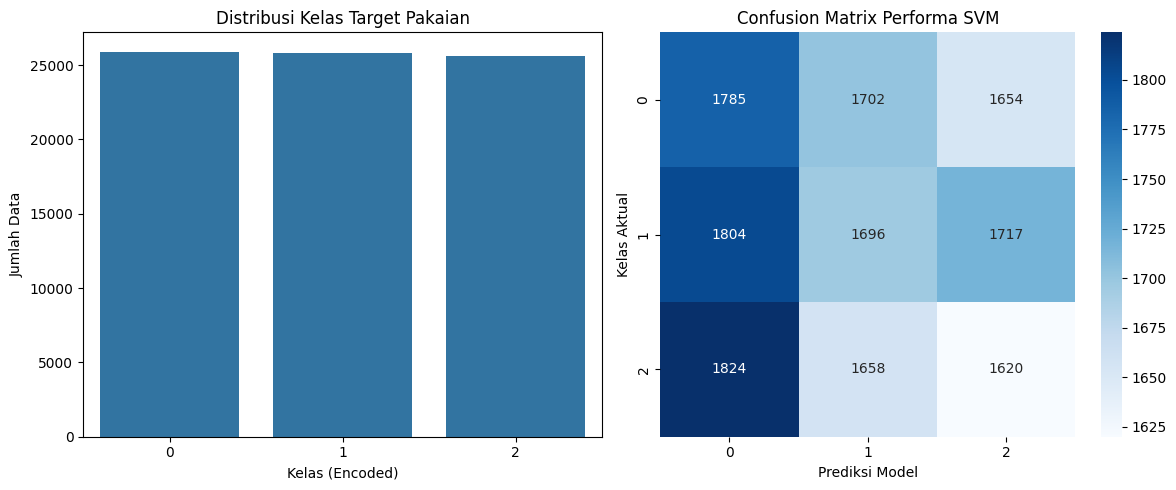

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("=== LANGKAH 6: MEMPROSES VISUALISASI ===")
plt.figure(figsize=(12, 5))

# Visualisasi 1: Distribusi Kelas Target
plt.subplot(1, 2, 1)
sns.countplot(x=y)
plt.title("Distribusi Kelas Target Pakaian")
plt.xlabel("Kelas (Encoded)")
plt.ylabel("Jumlah Data")

# Visualisasi 2: Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix Performa SVM")
plt.xlabel("Prediksi Model")
plt.ylabel("Kelas Aktual")

plt.tight_layout()
plt.show()